In [1]:
import pandas as pd
import numpy as np

In [2]:
df_model = pd.read_csv('for_train.csv', encoding="utf-8-sig")

In [4]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111409 entries, 0 to 111408
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   จังหวัด             111409 non-null  object 
 1   รถคันที่1           111409 non-null  object 
 2   บริเวณที่เกิดเหตุ   111409 non-null  object 
 3   มูลเหตุสันนิษฐาน    111409 non-null  object 
 4   ลักษณะการเกิดเหตุ   111409 non-null  object 
 5   สภาพอากาศ           111409 non-null  object 
 6   LATITUDE            111409 non-null  float64
 7   LONGITUDE           111409 non-null  float64
 8   ชั่วโมง             111409 non-null  int64  
 9   year                111409 non-null  int64  
 10  month               111409 non-null  int64  
 11  day                 111409 non-null  int64  
 12  is_weekend          111409 non-null  int64  
 13  time_period         111409 non-null  object 
 14  severity_level      111409 non-null  object 
 15  is_new_year         111409 non-nul

In [3]:
drop_list = [
    'รถจักรยานยนต์',
    'รถสามล้อเครื่อง',
    'รถยนต์นั่งส่วนบุคคล',
    'รถตู้',
    'รถปิคอัพโดยสาร',
    'รถโดยสารมากกว่า4ล้อ',
    'รถปิคอัพบรรทุก4ล้อ',
    'รถบรรทุก6ล้อ',
    'รถบรรทุกไม่เกิน10ล้อ',
    'รถบรรทุกมากกว่า10ล้อ',
    'รถอีแต๋น',
    'รถอื่นๆ',
    'คนเดินเท้า',
    'รหัสสายทาง',
    'หน่วยงาน',
    'สายทาง',
]

df_model = df_model.drop(columns=[col for col in drop_list if col in df_model.columns])
df_model.to_csv('for_train.csv', index=False, encoding='utf-8-sig')
print("บันทึกแล้ว")

บันทึกแล้ว


In [28]:
df_model.isnull().sum()

จังหวัด               0
รถคันที่1             0
บริเวณที่เกิดเหตุ     0
มูลเหตุสันนิษฐาน      0
ลักษณะการเกิดเหตุ     0
สภาพอากาศ             0
LATITUDE              0
LONGITUDE             0
ชั่วโมง               0
year                  0
month                 0
day                   0
is_weekend            0
time_period           0
severity_level        0
is_new_year           0
is_songkran           0
is_dangerous_7days    0
dtype: int64

In [29]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111409 entries, 0 to 111408
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   จังหวัด             111409 non-null  object 
 1   รถคันที่1           111409 non-null  object 
 2   บริเวณที่เกิดเหตุ   111409 non-null  object 
 3   มูลเหตุสันนิษฐาน    111409 non-null  object 
 4   ลักษณะการเกิดเหตุ   111409 non-null  object 
 5   สภาพอากาศ           111409 non-null  object 
 6   LATITUDE            111409 non-null  float64
 7   LONGITUDE           111409 non-null  float64
 8   ชั่วโมง             111409 non-null  int64  
 9   year                111409 non-null  int64  
 10  month               111409 non-null  int64  
 11  day                 111409 non-null  int64  
 12  is_weekend          111409 non-null  int64  
 13  time_period         111409 non-null  object 
 14  severity_level      111409 non-null  object 
 15  is_new_year         111409 non-nul

In [3]:
x = pd.get_dummies(df_model.drop(columns=['severity_level']))
y = df_model['severity_level']

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [7]:
model.score(x_train, y_train)

0.9998765806096918

In [14]:
model = RandomForestClassifier(
    n_estimators=100,       
    max_depth=12,           
    min_samples_split=10,
    class_weight='balanced',
    min_samples_leaf=5,     
    random_state=42,
    n_jobs=-1               
)

model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
model.score(x_train, y_train)

0.7336272958811584

In [21]:
from sklearn.metrics import classification_report, confusion_matrix

y_predict = model.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_predict,
      target_names=['รุนแรงน้อย', 'รุนแรงปานกลาง', 'รุนแรงมาก']))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_predict))

Classification Report:
               precision    recall  f1-score   support

   รุนแรงน้อย       0.92      0.79      0.85     18174
รุนแรงปานกลาง       0.19      0.26      0.22      1664
    รุนแรงมาก       0.33      0.60      0.43      2444

     accuracy                           0.73     22282
    macro avg       0.48      0.55      0.50     22282
 weighted avg       0.80      0.73      0.76     22282

Confusion Matrix:
[[14317  1532  2325]
 [  629   429   606]
 [  632   341  1471]]


In [22]:
import joblib

joblib.dump(model, 'accident_model.pkl')
joblib.dump(x.columns, 'model_columns.pkl')

['model_columns.pkl']

In [23]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [24]:
import shap
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

In [25]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test)

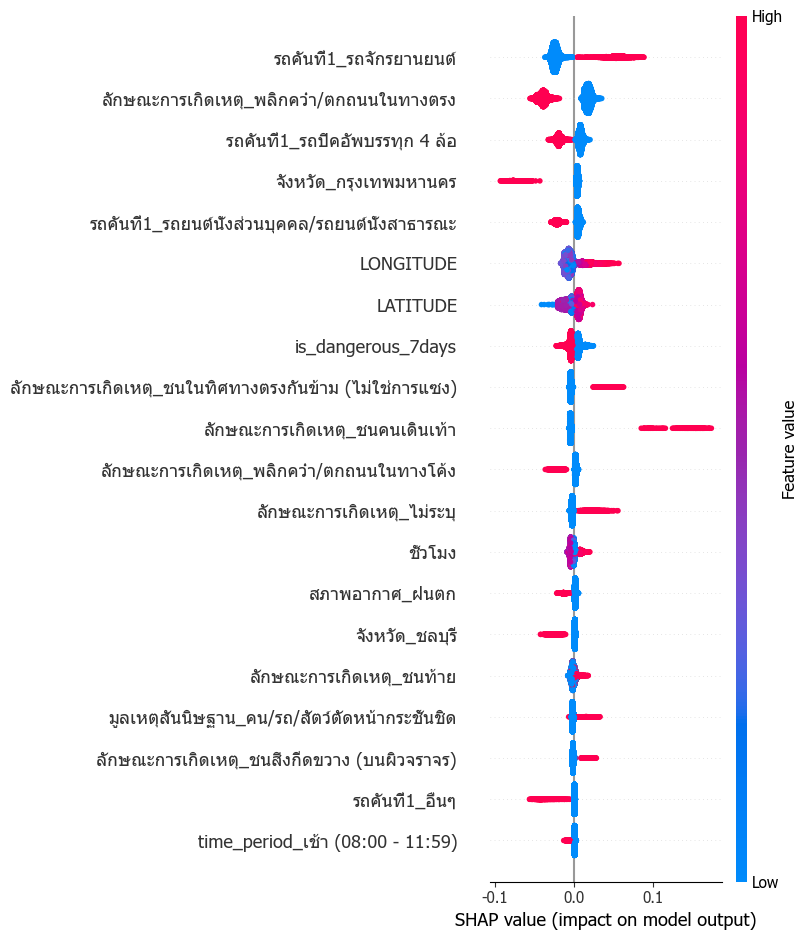

In [28]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False  

if isinstance(shap_values, list):
    sv_class2 = shap_values[2]
else:
    sv_class2 = shap_values[:, :, 2]

shap.summary_plot(
    sv_class2,
    x_test,
    plot_type="dot"
)